In [1]:
import pandas as pd

df = pd.read_csv('2019-Nov_smartphone_preprocessed_final.csv')

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,is_price_error,hour,day_of_week,day_name,time_segment,is_outlier,is_purchase,is_cart
0,2019-11-01 09:00:00,view,1003461,-1769995873,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33,False,9,4,Friday,오전 (6-12시),False,0,0
1,2019-11-01 09:00:01,view,1004775,-1769995873,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2,False,9,4,Friday,오전 (6-12시),False,0,0
2,2019-11-01 09:00:02,view,1004258,-1769995873,electronics.smartphone,apple,732.07,532647354,d2d3d2c6-631d-489e-9fb5-06f340b85be0,False,9,4,Friday,오전 (6-12시),False,0,0
3,2019-11-01 09:00:07,view,1004566,-1769995873,electronics.smartphone,huawei,164.84,566265908,52c2c76c-b79e-4794-86ff-badc76d35f5a,False,9,4,Friday,오전 (6-12시),False,0,0
4,2019-11-01 09:00:08,view,1004708,-1769995873,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843,False,9,4,Friday,오전 (6-12시),False,0,0


In [2]:
grouped = df.groupby(['user_session', 'product_id'])

view 집계 = 브랜드 노출도 분포 확인

In [3]:
brand_view = (
    df[df['event_type'] == 'view']
    .groupby('brand')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='view_count')
)

brand_view.head(10)

,brand,view_count
0,samsung,4691821
1,apple,4157650
2,xiaomi,3093796
3,huawei,1148965
4,oppo,751897
5,meizu,193806
6,vivo,151465
7,oneplus,107339
8,honor,105051
9,nokia,91206


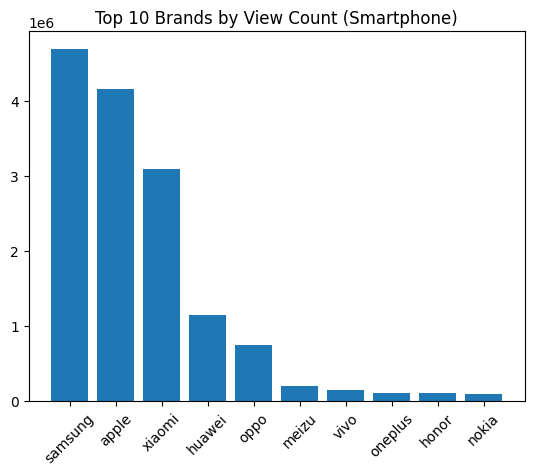

In [4]:
#시각화
import matplotlib.pyplot as plt

top10 = brand_view.head(10)

plt.figure()
plt.bar(top10['brand'], top10['view_count'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by View Count (Smartphone)')
plt.show()

purchase count = 상품 수량x, 구매 도달 횟수

revenue = 브랜드 수익 추정치

In [5]:
brand_revenue_detail = (
    df[df['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .sort_values(by='revenue', ascending=False)
    .reset_index()
)

brand_revenue_detail.head(10)

,brand,revenue,purchase_count,avg_price
0,apple,1.138908e+08,125768,905.562660
1,samsung,4.245160e+07,160830,263.953259
2,xiaomi,9.765678e+06,48145,202.838872
3,huawei,4.505991e+06,21500,209.580976
4,oppo,3.474445e+06,15022,231.290434
5,vivo,5.087563e+05,1891,269.040857
6,oneplus,3.467014e+05,529,655.390151
7,meizu,2.683712e+05,2084,128.776972
8,sony,1.794730e+05,455,394.446264
9,honor,1.757745e+05,695,252.912906


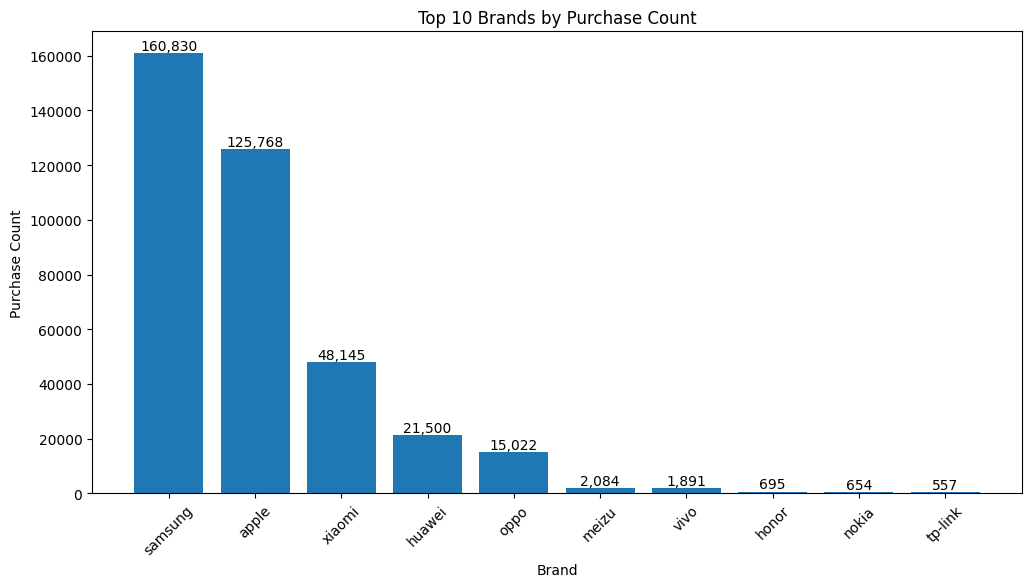

In [6]:
import matplotlib.pyplot as plt

top10_brand_count = (brand_revenue_detail
                    .sort_values('purchase_count', ascending=False)
                    .head(10))


plt.figure(figsize=(12,6))

bars = plt.bar(
    top10_brand_count['brand'],
    top10_brand_count['purchase_count']
)

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.ylabel('Purchase Count')
plt.xlabel('Brand')
plt.title('Top 10 Brands by Purchase Count')

plt.show()

산점도

브랜드 퍼널 분류

In [7]:
df = df.sort_values(['user_session', 'event_time']).copy()

grouped = df.groupby(['user_session', 'brand'])

In [8]:
result = []
for (session, brand), group in grouped:
    group = group.sort_values('event_time')  
    events = group['event_type'].tolist()

    
    # index 찾기
    view_idx = next((i for i, e in enumerate(events) if e == 'view'), None)
    cart_idx = next((i for i, e in enumerate(events) if e == 'cart'), None)
    purchase_idx = next((i for i, e in enumerate(events) if e == 'purchase'), None)
    
    has_view = view_idx is not None
    valid_view_cart = view_idx is not None and cart_idx is not None and view_idx < cart_idx
    valid_cart_purchase = cart_idx is not None and purchase_idx is not None and cart_idx < purchase_idx
    
    result.append([
        session, brand,
        has_view,
        valid_view_cart,
        valid_cart_purchase
    ])

funnel_df = pd.DataFrame(result, columns=[
    'user_session', 'brand',
    'view', 'view_to_cart', 'cart_to_purchase'
])

In [9]:
import numpy as np
import pandas as pd

# 브랜드별 퍼널 집계
brand_funnel = (
    funnel_df.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel['view_to_cart_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['view_to_cart_sessions'] / brand_funnel['view_sessions'],
    0
)

brand_funnel['cart_to_purchase_rate'] = np.where(
    brand_funnel['view_to_cart_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_to_cart_sessions'],
    0
)

brand_funnel['total_conversion_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_sessions'],
    0
)

# 이탈률
brand_funnel['drop_view_to_cart'] = 1 - brand_funnel['view_to_cart_rate']
brand_funnel['drop_cart_to_purchase'] = 1 - brand_funnel['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel = brand_funnel[brand_funnel['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue = (
    df[df['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis = brand_funnel.merge(
    brand_revenue,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis = brand_analysis.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis[rate_cols] = brand_analysis[rate_cols] * 100

brand_analysis.head(20)

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
28,samsung,1682093,263111,123393,15.641882,46.897697,7.335682,84.358118,53.102303,4.245160e+07,160830.0,263.953259
0,apple,1579708,227469,93359,14.399433,41.042516,5.909890,85.600567,58.957484,1.138908e+08,125768.0,905.562660
24,oppo,284527,26544,12053,9.329167,45.407625,4.236153,90.670833,54.592375,3.474445e+06,15022.0,231.290434
37,xiaomi,921392,107033,37712,11.616446,35.233993,4.092938,88.383554,64.766007,9.765678e+06,48145.0,202.838872
11,huawei,420221,39452,17161,9.388393,43.498428,4.083804,90.611607,56.501572,4.505991e+06,21500.0,209.580976
32,tp-link,14679,742,390,5.054840,52.560647,2.656857,94.945160,47.439353,6.555286e+04,557.0,117.689156
36,vivo,55831,3558,1466,6.372804,41.202923,2.625781,93.627196,58.797077,5.087563e+05,1891.0,269.040857
19,meizu,80053,3882,1548,4.849287,39.876352,1.933719,95.150713,60.123648,2.683712e+05,2084.0,128.776972
27,prestigio,7587,334,140,4.402267,41.916168,1.845262,95.597733,58.083832,1.009955e+04,188.0,53.721011
5,fly,1279,37,21,2.892885,56.756757,1.641908,97.107115,43.243243,1.313370e+03,29.0,45.288621


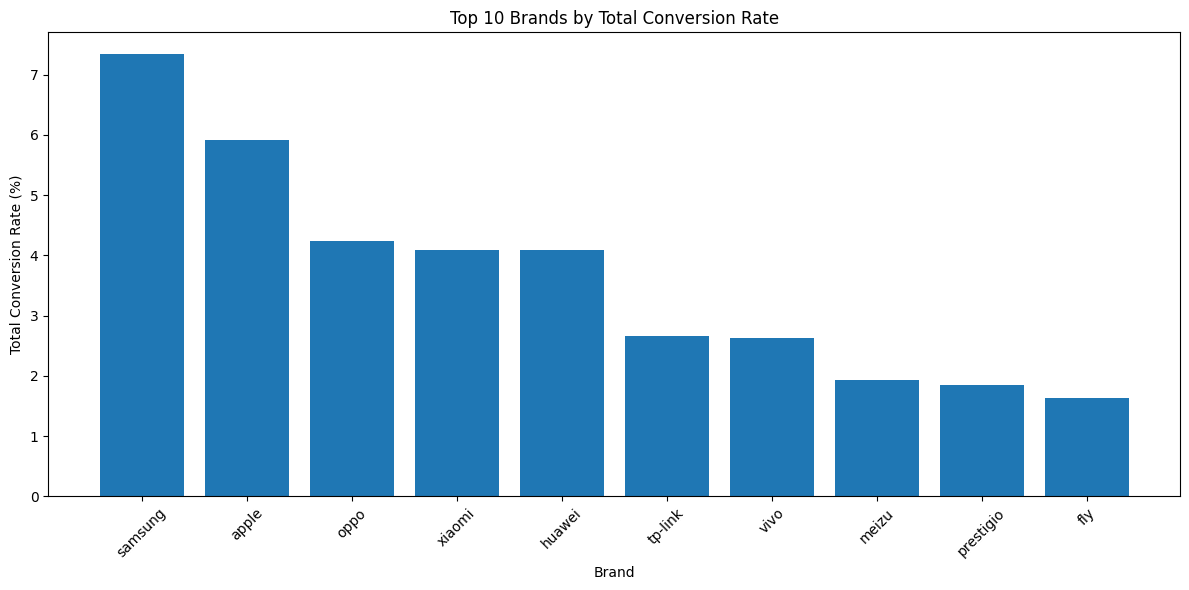

In [10]:
import matplotlib.pyplot as plt

top10_conv = brand_analysis.sort_values(
    by='total_conversion_rate', ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_conv['brand'], top10_conv['total_conversion_rate'])
plt.xticks(rotation=45)
plt.title('Top 10 Brands by Total Conversion Rate')
plt.xlabel('Brand')
plt.ylabel('Total Conversion Rate (%)')
plt.tight_layout()
plt.show()

산점도

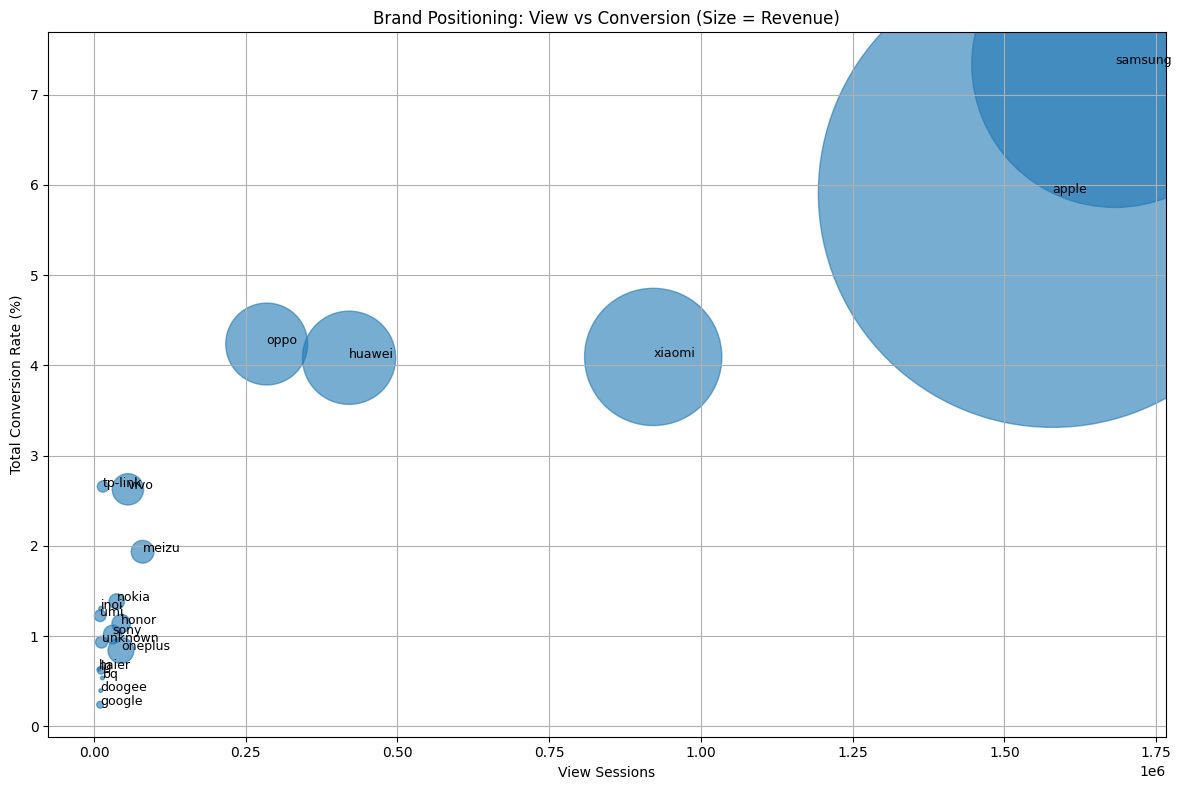

In [11]:
import matplotlib.pyplot as plt

# 상위 브랜드만 (노이즈 제거)
plot_df = brand_analysis.sort_values(
    by='view_sessions', ascending=False
).head(20).copy()

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_df['view_sessions'],                 # X축: 조회 수
    plot_df['total_conversion_rate'],        # Y축: 전환율
    s=plot_df['revenue'] / 1000,             # 점 크기: 매출 (스케일 조정)
    alpha=0.6
)

# 브랜드 이름 표시
for i, row in plot_df.iterrows():
    plt.text(
        row['view_sessions'],
        row['total_conversion_rate'],
        row['brand'],
        fontsize=9
    )

plt.xlabel('View Sessions')
plt.ylabel('Total Conversion Rate (%)')
plt.title('Brand Positioning: View vs Conversion (Size = Revenue)')
plt.grid(True)
plt.tight_layout()
plt.show()

세부 분석

1. 퍼널 분해

In [12]:
target_brands = ['apple', 'samsung', 'xiaomi']

compare_df = brand_analysis[
    brand_analysis['brand'].str.lower().isin(target_brands)
].copy()

compare_df

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price
28,samsung,1682093,263111,123393,15.641882,46.897697,7.335682,84.358118,53.102303,4.245160e+07,160830.0,263.953259
0,apple,1579708,227469,93359,14.399433,41.042516,5.909890,85.600567,58.957484,1.138908e+08,125768.0,905.562660
37,xiaomi,921392,107033,37712,11.616446,35.233993,4.092938,88.383554,64.766007,9.765678e+06,48145.0,202.838872


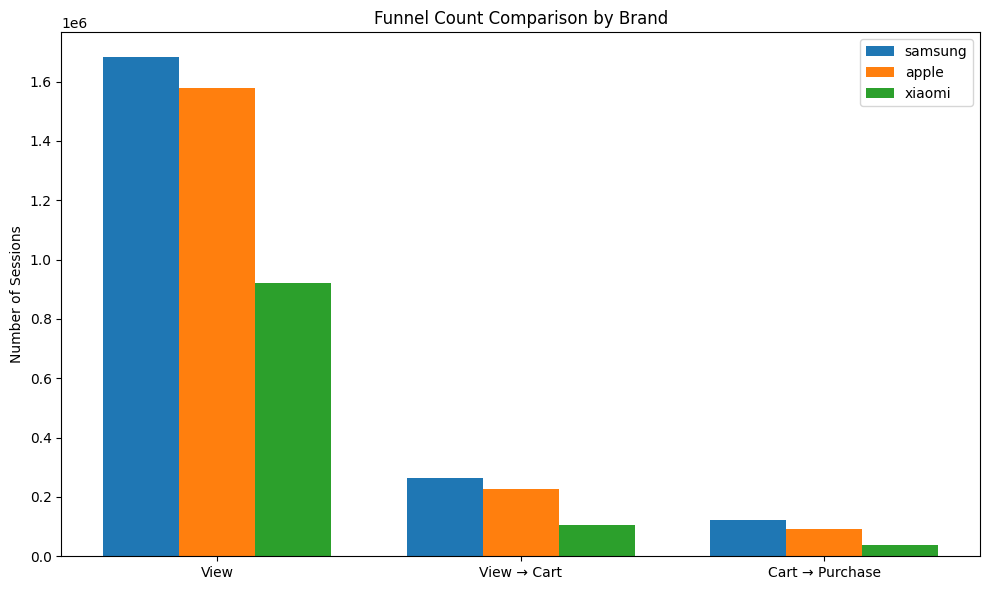

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 퍼널 단계
stages = ['View', 'View → Cart', 'Cart → Purchase']
x = np.arange(len(stages))
width = 0.25

plt.figure(figsize=(10, 6))

for i, row in enumerate(compare_df.itertuples()):
    values = [
        row.view_sessions,
        row.view_to_cart_sessions,
        row.cart_to_purchase_sessions
    ]
    
    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=row.brand
    )

plt.xticks(x, stages)
plt.ylabel('Number of Sessions')
plt.title('Funnel Count Comparison by Brand')
plt.legend()
plt.tight_layout()
plt.show()

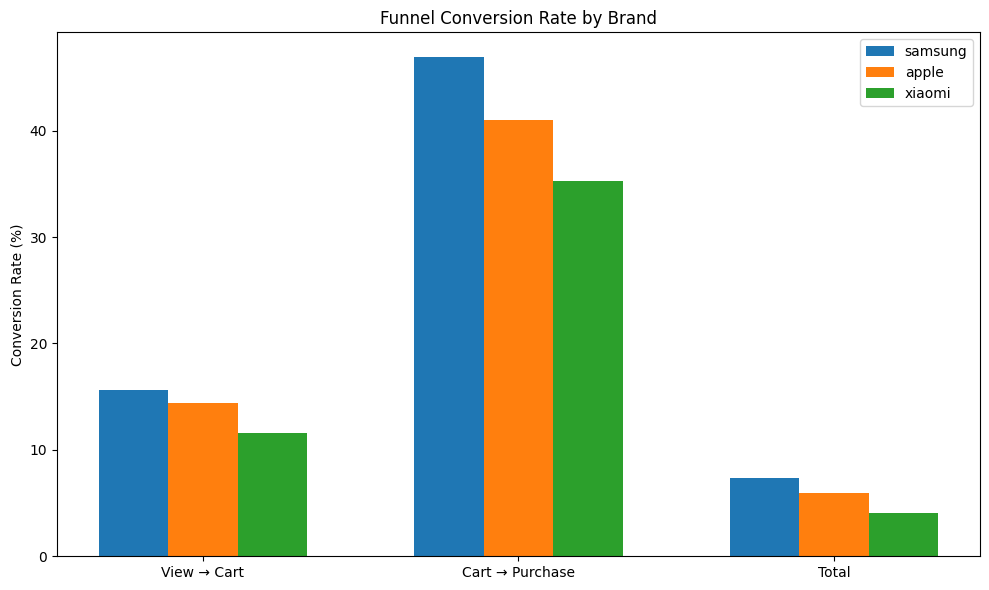

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = compare_df.copy()

rate_labels = [
    'View → Cart',
    'Cart → Purchase',
    'Total'
]

x = np.arange(len(rate_labels))
width = 0.22

plt.figure(figsize=(10, 6))

for i, row in enumerate(plot_df.itertuples()):
    values = [
        row.view_to_cart_rate,
        row.cart_to_purchase_rate,
        row.total_conversion_rate
    ]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=row.brand
    )

plt.xticks(x, rate_labels)
plt.ylabel('Conversion Rate (%)')
plt.title('Funnel Conversion Rate by Brand')
plt.legend()
plt.tight_layout()

plt.show()

2. 브랜드 별 판매가 (수량 파악 불가, 브랜드 파워 고려 -> 이상치 처리x) 추정치, 경향 파악 보조 해석 

In [21]:
target_brands = ['apple', 'samsung', 'xiaomi']

brand_order = ['samsung', 'apple', 'xiaomi']

df_target = df[df['brand'].str.lower().isin(target_brands)].copy()

df_target['brand'] = pd.Categorical(
    df_target['brand'],
    categories=brand_order,
    ordered=True
)

In [22]:
#2 브랜드별 평균 / 중앙 판매가
brand_price_detail = (
    df_target[df_target['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean'),
        median_price=('price', 'median'),
        min_price=('price', 'min'),
        max_price=('price', 'max')
    )
    .reset_index()
)

brand_price_detail

,brand,purchase_count,avg_price,median_price,min_price,max_price
0,samsung,160830,263.953259,195.85,84.86,2562.49
1,apple,125768,905.562660,915.08,283.12,2053.55
2,xiaomi,48145,202.838872,198.36,66.35,738.76


In [23]:
# compare_df에 median_price 붙이기
plot_df = compare_df.merge(
    brand_price_detail[['brand', 'median_price']],
    on='brand',
    how='left'
)

plot_df

,brand,view_sessions,view_to_cart_sessions,cart_to_purchase_sessions,view_to_cart_rate,cart_to_purchase_rate,total_conversion_rate,drop_view_to_cart,drop_cart_to_purchase,revenue,purchase_count,avg_price,median_price
0,samsung,1682093,263111,123393,15.641882,46.897697,7.335682,84.358118,53.102303,4.245160e+07,160830.0,263.953259,195.85
1,apple,1579708,227469,93359,14.399433,41.042516,5.909890,85.600567,58.957484,1.138908e+08,125768.0,905.562660,915.08
2,xiaomi,921392,107033,37712,11.616446,35.233993,4.092938,88.383554,64.766007,9.765678e+06,48145.0,202.838872,198.36


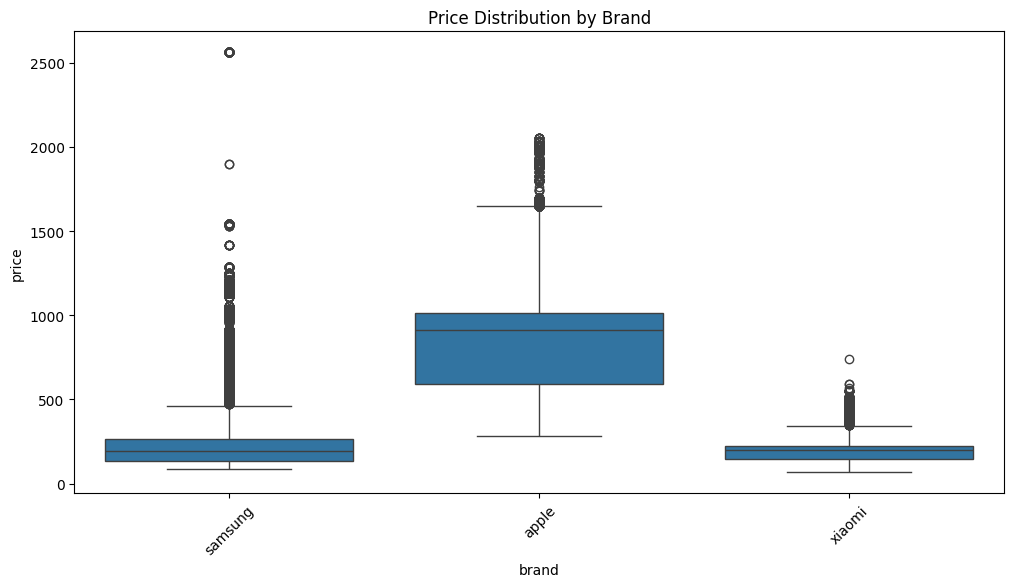

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

purchase_df = df_target[df_target['event_type'] == 'purchase']

top_brands = purchase_df['brand'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(
    data=purchase_df[purchase_df['brand'].isin(top_brands)],
    x='brand',
    y='price'
)
plt.xticks(rotation=45)
plt.title('Price Distribution by Brand')
plt.show()

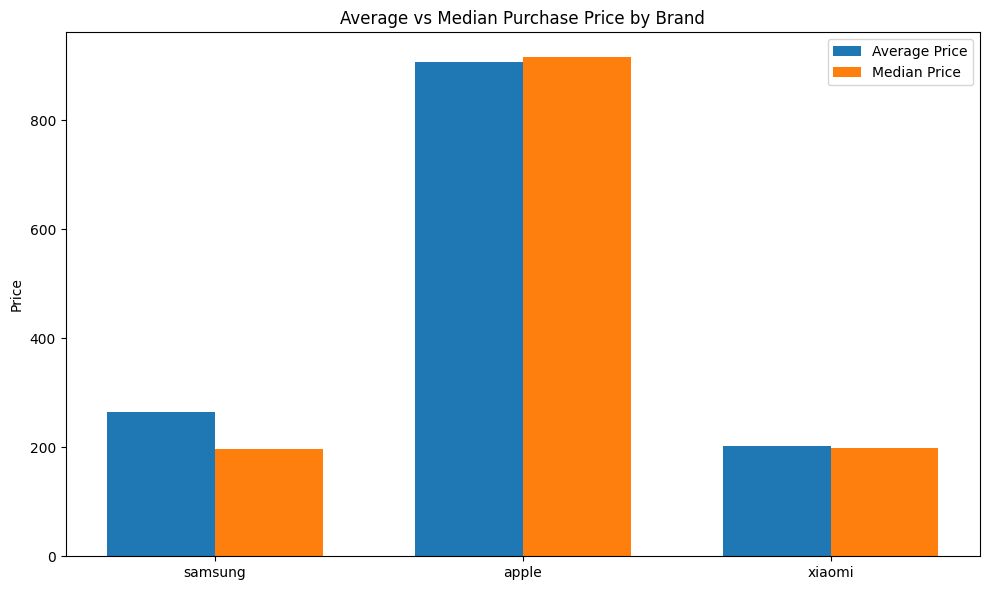

In [25]:
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df['avg_price'], width, label='Average Price')
plt.bar(x + width/2, plot_df['median_price'], width, label='Median Price')

plt.xticks(x, plot_df['brand'])
plt.ylabel('Price')
plt.title('Average vs Median Purchase Price by Brand')
plt.legend()
plt.tight_layout()
plt.show()

3. 상위 주력 상품 비율

In [26]:
#3. 상위 매출 product_id 비중
#몇 개 주력 모델에 몰려 있는지
product_revenue = (
    df_target[df_target['event_type'] == 'purchase']
    .groupby(['brand', 'product_id'])
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count')
    )
    .reset_index()
)

product_revenue

,brand,product_id,revenue,purchase_count
0,samsung,1000978,6135.32,20
1,samsung,1002062,688.27,6
2,samsung,1002098,10175.50,26
3,samsung,1002100,19951.84,53
4,samsung,1002101,60765.02,160
...,...,...,...,...
445,xiaomi,100014109,9239.11,42
446,xiaomi,100015032,10543.40,48
447,xiaomi,100019218,4648.25,20
448,xiaomi,100020739,701.94,4


In [27]:
#상위 1개 / 3개 / 5개 상품 비중
def top_n_share(group, n):
    return group.sort_values('revenue', ascending=False).head(n)['revenue'].sum() / group['revenue'].sum()

top_share_rows = []

for brand, group in product_revenue.groupby('brand'):
    top_share_rows.append({
        'brand': brand,
        'top1_revenue_share': top_n_share(group, 1),
        'top3_revenue_share': top_n_share(group, 3),
        'top5_revenue_share': top_n_share(group, 5)
    })

top_share_df = pd.DataFrame(top_share_rows)
top_share_df

,brand,top1_revenue_share,top3_revenue_share,top5_revenue_share
0,samsung,0.130240,0.297919,0.404107
1,apple,0.179419,0.340840,0.448767
2,xiaomi,0.141052,0.278954,0.390475


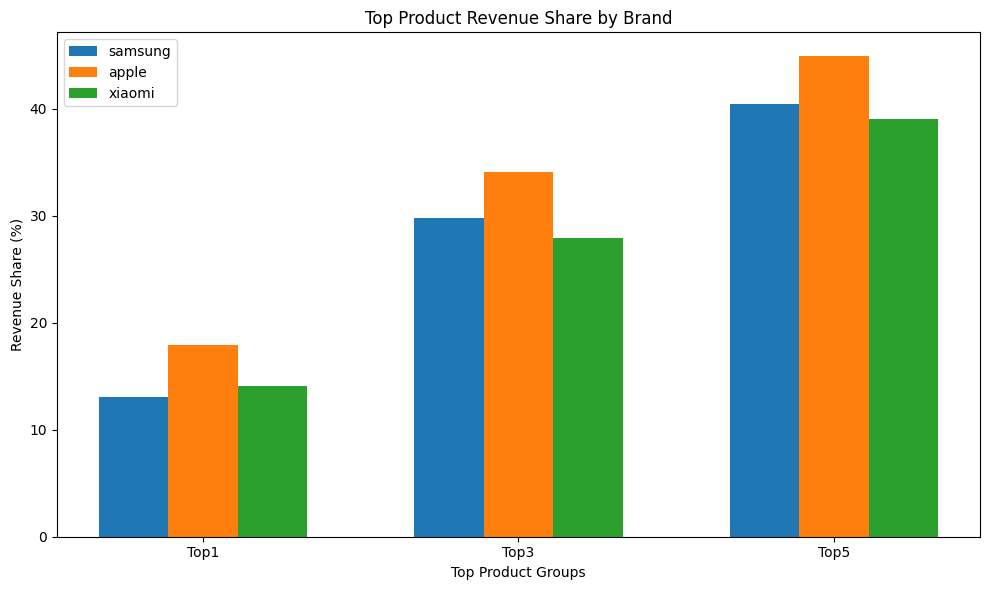

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 퍼센트 변환
brand_order = ['samsung', 'apple', 'xiaomi']

plot_df = top_share_df.copy()

plot_df['brand'] = pd.Categorical(
    plot_df['brand'],
    categories=brand_order,
    ordered=True
)

plot_df = plot_df.sort_values('brand')

share_cols = [
    'top1_revenue_share',
    'top3_revenue_share',
    'top5_revenue_share'
]

plot_df[share_cols] = plot_df[share_cols] * 100

# x축
share_labels = ['Top1', 'Top3', 'Top5']
x = np.arange(len(share_labels))
width = 0.22

plt.figure(figsize=(10, 6))

for i, row in enumerate(plot_df.itertuples()):
    values = [
        row.top1_revenue_share,
        row.top3_revenue_share,
        row.top5_revenue_share
    ]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=row.brand
    )

plt.xticks(x, share_labels)
plt.ylabel('Revenue Share (%)')
plt.xlabel('Top Product Groups')
plt.title('Top Product Revenue Share by Brand')
plt.legend()
plt.tight_layout()

plt.show()

4. 세션 당 조회 상품 수

In [29]:
views_target = df_target[df_target['event_type'] == 'view'].copy()

session_view_depth = (
    views_target.groupby(['brand', 'user_session'])
    .agg(
        view_event_count=('product_id', 'size'),
        unique_view_products=('product_id', 'nunique')
    )
    .reset_index()
)

session_view_depth.head()

,brand,user_session,view_event_count,unique_view_products
0,samsung,000009c4-a1dd-4764-87d9-24f3d7e43c4f,4,2
1,samsung,00000c2a-aada-4ee8-a0ae-1948795f4d34,1,1
2,samsung,00003dca-5a5a-4af2-86ef-9851ceb02a2b,2,1
3,samsung,00004f6c-989d-43f7-b68a-7634086b95a6,2,1
4,samsung,00005ea5-e83e-47aa-b249-72ca272d6df9,4,3


In [30]:
brand_session_view_depth = (
    session_view_depth.groupby('brand')
    .agg(
        avg_view_events_per_session=('view_event_count', 'mean'),
        median_view_events_per_session=('view_event_count', 'median'),
        avg_unique_products_per_session=('unique_view_products', 'mean'),
        median_unique_products_per_session=('unique_view_products', 'median')
    )
    .reset_index()
)

brand_session_view_depth

,brand,avg_view_events_per_session,median_view_events_per_session,avg_unique_products_per_session,median_unique_products_per_session
0,samsung,2.789276,2.0,1.833453,1.0
1,apple,2.631910,2.0,1.787497,1.0
2,xiaomi,3.357741,2.0,1.974127,1.0


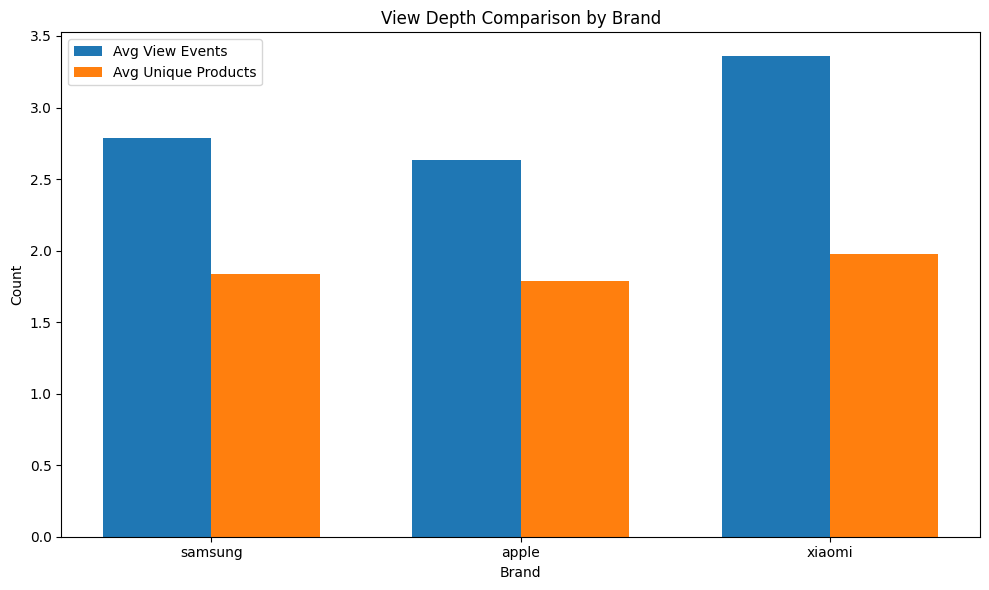

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 브랜드 순서 지정
brand_order = ['samsung', 'apple', 'xiaomi']

plot_df = brand_session_view_depth.copy()

plot_df['brand'] = pd.Categorical(
    plot_df['brand'],
    categories=brand_order,
    ordered=True
)

plot_df = plot_df.sort_values('brand')

# x축
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

# 평균 조회 이벤트 수
plt.bar(
    x - width/2,
    plot_df['avg_view_events_per_session'],
    width,
    label='Avg View Events'
)

# 평균 고유 상품 수
plt.bar(
    x + width/2,
    plot_df['avg_unique_products_per_session'],
    width,
    label='Avg Unique Products'
)

# 축 설정
plt.xticks(x, plot_df['brand'])
plt.ylabel('Count')
plt.xlabel('Brand')
plt.title('View Depth Comparison by Brand')

plt.legend()
plt.tight_layout()

plt.show()

5. 동일 세션 내 모델 비교 깊이

In [32]:
brand_session_compare = (
    views_target.groupby(['brand', 'user_session'])
    .agg(
        unique_models_compared=('product_id', 'nunique')
    )
    .reset_index()
)

brand_session_compare.head()

,brand,user_session,unique_models_compared
0,samsung,000009c4-a1dd-4764-87d9-24f3d7e43c4f,2
1,samsung,00000c2a-aada-4ee8-a0ae-1948795f4d34,1
2,samsung,00003dca-5a5a-4af2-86ef-9851ceb02a2b,1
3,samsung,00004f6c-989d-43f7-b68a-7634086b95a6,1
4,samsung,00005ea5-e83e-47aa-b249-72ca272d6df9,3


In [33]:
brand_compare_depth = (
    brand_session_compare.groupby('brand')
    .agg(
        avg_model_compare_depth=('unique_models_compared', 'mean'),
        median_model_compare_depth=('unique_models_compared', 'median'),
        max_model_compare_depth=('unique_models_compared', 'max')
    )
    .reset_index()
)

brand_compare_depth

,brand,avg_model_compare_depth,median_model_compare_depth,max_model_compare_depth
0,samsung,1.833453,1.0,49
1,apple,1.787497,1.0,89
2,xiaomi,1.974127,1.0,57


In [34]:
compare_ratio = (
    brand_session_compare.groupby('brand')
    .apply(lambda g: pd.Series({
        'compare_2plus_session_ratio': (g['unique_models_compared'] >= 2).mean(),
        'compare_3plus_session_ratio': (g['unique_models_compared'] >= 3).mean()
    }))
    .reset_index()
)

compare_ratio

,brand,compare_2plus_session_ratio,compare_3plus_session_ratio
0,samsung,0.360611,0.185487
1,apple,0.360851,0.175250
2,xiaomi,0.381120,0.208905


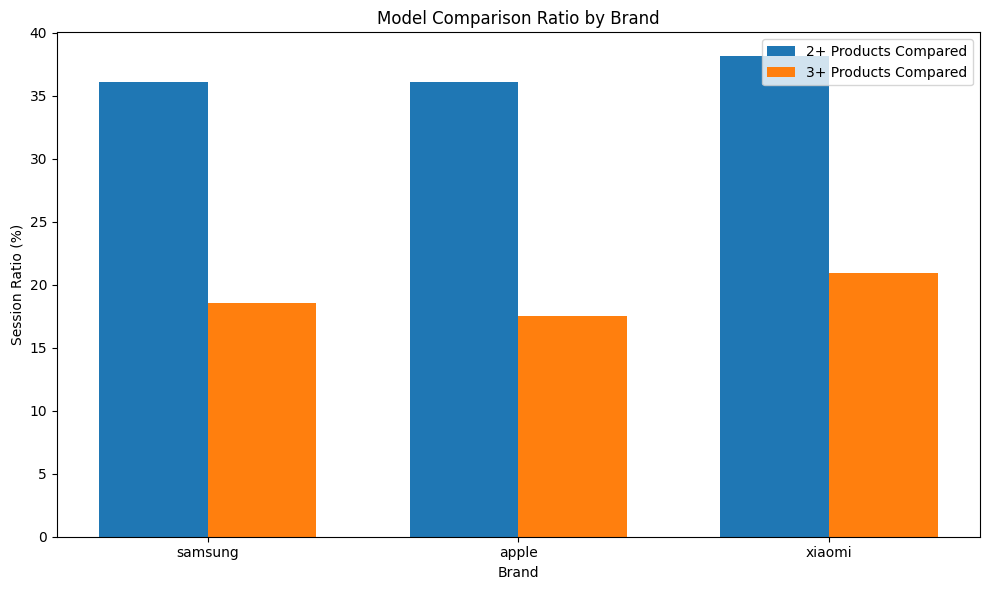

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 브랜드 순서 지정
brand_order = ['samsung', 'apple', 'xiaomi']

plot_df = compare_ratio.copy()

plot_df['brand'] = pd.Categorical(
    plot_df['brand'],
    categories=brand_order,
    ordered=True
)

plot_df = plot_df.sort_values('brand')

# 퍼센트 변환
plot_df['compare_2plus_session_ratio'] *= 100
plot_df['compare_3plus_session_ratio'] *= 100

# x축
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

# 2개 이상 비교 비율
plt.bar(
    x - width/2,
    plot_df['compare_2plus_session_ratio'],
    width,
    label='2+ Products Compared'
)

# 3개 이상 비교 비율
plt.bar(
    x + width/2,
    plot_df['compare_3plus_session_ratio'],
    width,
    label='3+ Products Compared'
)

# 축 설정
plt.xticks(x, plot_df['brand'])
plt.ylabel('Session Ratio (%)')
plt.xlabel('Brand')
plt.title('Model Comparison Ratio by Brand')

plt.legend()
plt.tight_layout()

plt.show()

스마트폰 데이터의 분포 
view=노출도
purchase count=수량x
revenue=수익추정치
->산점도 제시
3가지 브랜드만을 보는 근거 제시
->브랜드별 유형 + 브랜드의 유저에게 미치는 의미 가설 제시
삼성은 규모와 효율을 동시에 확보한 시장 지배형 브랜드,
애플은 높은 매출을 만드는 프리미엄 수익형 브랜드,
샤오미는 탐색은 많지만 전환이 낮은 비교형 브랜드

서브퍼널 brand + user session
1.퍼널 분해
전환율 표
2.브랜드별 판매가 (수량 파악 불가 -> 이상치 처리x) 추정치 경향으로 봐야함
iqr 표 + 시각화 표
3.상위 주력 상품 비율
4.깊이

10월 11월 공통 경향 + 차이점
1. 삼성은 유입도 크고 카트에 담고 총 전환도 큼
2. 애플은 매출이 압도적
3. 샤오미는 여전히 자체 제품군 비교 및 탐색 깊이가 깊은 경향 

차이점
1. 애플의 추정 평단가가 증가함 (신제품 혹은 고가 제품군 영향?)
2. top3,5 구매 비중 삼성을 애플이 역전함 (11월에 애플 인기 상위 모델에 급격히 집중되는 경향)

결론
시장 구조 핵심 인사이트
조회가 많다고 구매가 많은 건 아니다 → 샤오미 사례
매출은 전환율보다 가격의 영향을 더 크게 받는다→ 애플 사례
브랜드마다 소비자 행동 구조 자체가 다르다
→ 탐색형 vs 충성형 vs 대중형

“브랜드는 단순히 제품이 아니라 소비자의 행동을 바꾼다”

+ '11월에 애플 기업의 변화가 있을 것'